In [3]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H2分子的几何构型
bond_length = 1.74  # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hartree-Fock能量: -0.84390759 Ha
FCI能量: -0.96730577 Ha


SpinOrbitalFermions 是 NetKet（特别是 netket ≥ v3.10 之后，或通过 netket.experimental）中用于描述具有自旋的费米子系统的希尔伯特空间（Hilbert space）类。它专为处理电子结构问题（如分子、固体中的多电子系统）而设计，天然支持泡利不相容原理和固定粒子数约束。

SpinOrbitalFermions 定义了一个由自旋轨道占据数构成的离散希尔伯特空间，每个自旋轨道只能被占据（1）或空（0），且满足：

费米子统计（自动通过占据数表示处理）
可选：固定总电子数、固定自旋向上/向下电子数


In [4]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(1, 1)  # 每种自旋的电子数
)

# 创建采样器 - 使用费米子跳跃采样器
# 对于分子系统，我们使用完整的轨道图（完全连接）
cluster = [(0,1),(2,3)]
#

# g = nk.graph.Graph(edges=[(0,2),(1,3),(2,0),(3,1)])
g = nk.graph.Graph(edges=[(0,1),(2,3)])
# g = nk.graph.Graph(edges=cluster)
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [5]:
hi.all_states()

Array([[0, 1, 0, 1],
       [0, 1, 1, 0],
       [1, 0, 0, 1],
       [1, 0, 1, 0]], dtype=int8)

In [10]:
import jax
import jax.numpy as jnp
from flax import nnx

class FFN_Amplitude(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        self.alpha = alpha
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs)

    def __call__(self, x: jax.Array):
        y = self.linear(x)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)
    

class FFN_Phase(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        self.alpha = alpha
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs)

    def __call__(self, x: jax.Array):
        y = self.linear(x)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)
    
class FFN(nnx.Module):
    def __init__(self,N:int,alpha:int,rngs_amplitude: nnx.Rngs,rngs_phase:nnx.Rngs) -> None:
        self.ffn_amplitude = FFN_Amplitude(N=N,alpha=alpha,rngs=rngs_amplitude)
        self.ffn_phase = FFN_Phase(N=N,alpha=alpha,rngs=rngs_phase)
        
    def __call__(self, x:jax.Array):
        y = self.ffn_amplitude(x) + 1j*self.ffn_phase(x)
        return y        

In [27]:
N = 4
ffnn_model = FFN(N=N, alpha=1, rngs_amplitude=nnx.Rngs(2),rngs_phase=nnx.Rngs(3))
vs = nk.vqs.MCState(sa, ffnn_model, n_discard_per_chain=10, n_samples=512)

# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)

# 运行优化
exp_name = "h2_molecule_ffnn_layer2"

In [28]:
gs.run(400, out=exp_name)

  0%|          | 0/400 [00:00<?, ?it/s]

100%|██████████| 400/400 [00:04<00:00, 86.38it/s, Energy=-0.96369+0.00000j ± 0.00060 [σ²=0.00018, R̂=1.0098]]


(JsonLog('h2_molecule_ffnn_layer2', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.02337646484375
   	Params: 0.0222930908203125,)

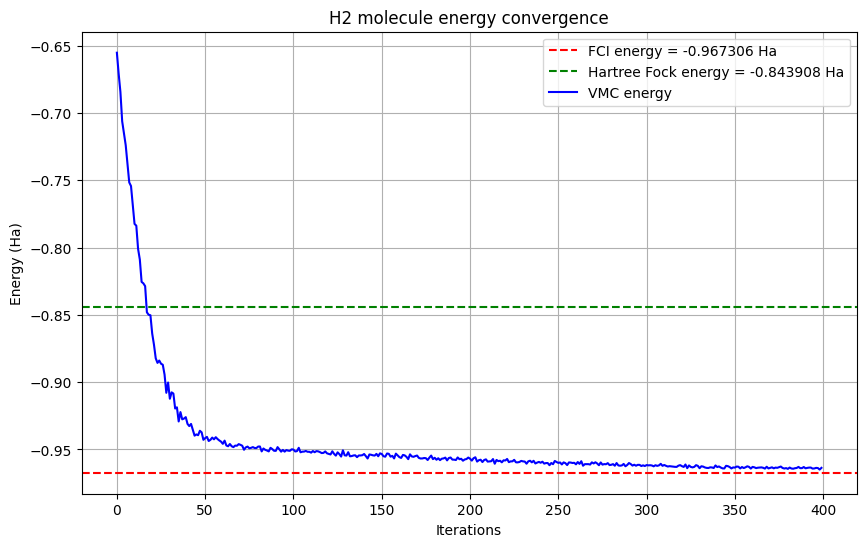

最终VMC能量: -0.96369351 Ha
最终FCI能量: -0.96730577 Ha
最终Hartree-Fock能量: -0.84390759 Ha
与FCI能量误差: 0.00361226 Ha


In [29]:
############## 绘图 #################
# 获取精确对角化能量（FCI能量）
exp_name = "h2_molecule_ffnn_layer2"
ed_energies = np.array([E_fci])  # H2只有一个基态能量

# 读取日志数据
with open(f"{exp_name}.log") as f:
    data = json.load(f)

x = data["Energy"]["iters"]
y = data["Energy"]["Mean"]['real']

# 绘制能量收敛曲线
plt.figure(figsize=(10, 6))
plt.axhline(ed_energies[0], color="red", linestyle="--", label=f"FCI energy = {E_fci:.6f} Ha")
plt.axhline(E_hf, color="green", linestyle="--", label=f"Hartree Fock energy = {E_hf:.6f} Ha")
plt.plot(x, y, 'b-', label="VMC energy")
plt.xlabel("Iterations")
plt.ylabel("Energy (Ha)")
plt.title("H2 molecule energy convergence")
plt.legend()
plt.grid(True)
plt.show()

# 打印最终结果
print(f"最终VMC能量: {y[-1]:.8f} Ha")
print(f"最终FCI能量: {E_fci:.8f} Ha")
print(f"最终Hartree-Fock能量: {E_hf:.8f} Ha")
print(f"与FCI能量误差: {abs(y[-1] - E_fci):.8f} Ha")


In [34]:
# 假设 vs 是你已经训练好的 MCState
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成大量样本以获得准确的概率分布
n_samples = 10000  # 增加样本数量以获得更准确的概率
samples = vs.sample(n_samples=n_samples)

# 2. 将样本重塑为二维数组 (n_samples, n_orbitals)
samples_flat = samples.reshape(-1, samples.shape[-1])

# 3. 统计每个组态的出现次数
unique_configs, counts = np.unique(samples_flat, axis=0, return_counts=True)

# 4. 计算概率
probabilities = counts / np.sum(counts)

# 5. 按概率排序
sorted_indices = np.argsort(probabilities)[::-1]
sorted_configs = unique_configs[sorted_indices]
sorted_probs = probabilities[sorted_indices]

print("组态及其概率分布:")
print("组态(轨道占据)    概率      物理解释")
print("-" * 50)
for i, (config, prob) in enumerate(zip(sorted_configs[:10], sorted_probs[:10])):  # 显示前10个主要组态
    # 解释组态的物理意义
    occupied_orbitals = np.where(config == 1)[0]
    print(f"{config}         {prob:.6f}   电子占据轨道: {occupied_orbitals}")


组态及其概率分布:
组态(轨道占据)    概率      物理解释
--------------------------------------------------
[1 0 1 0]         0.745600   电子占据轨道: [0 2]
[0 1 0 1]         0.191800   电子占据轨道: [1 3]
[0 1 1 0]         0.033300   电子占据轨道: [1 2]
[1 0 0 1]         0.029300   电子占据轨道: [0 3]
